<a href="https://colab.research.google.com/github/alfarisauliarahman/Alfaris-Aulia-Rahman_2411533006_ML2526/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train = pd.read_csv('/content/drive/MyDrive/ML/Dataset/train.csv')
test = pd.read_csv('/content/drive/MyDrive/ML/Dataset/test.csv')
gender_submission = pd.read_csv('/content/drive/MyDrive/ML/Dataset/gender_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())

Mounted at /content/drive
Train shape: (891, 12)
Test shape: (418, 11)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  

Survived
0    549
1    342
Name: count, dtype: int64


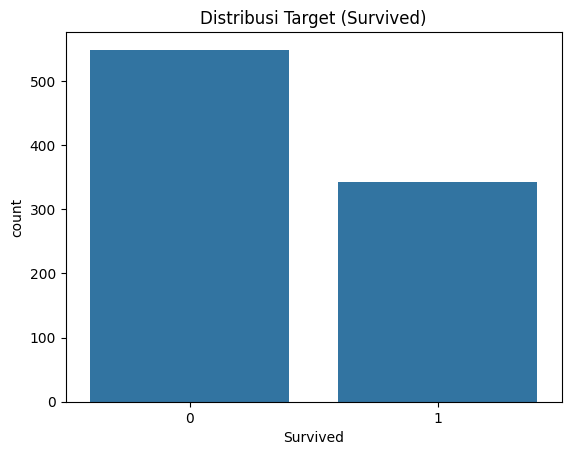


Missing Values di Train:
Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


In [ ]:
print(train['Survived'].value_counts())
sns.countplot(data=train, x='Survived')
plt.title('Distribusi Target (Survived)')
plt.show()

# Cek missing values
print("\nMissing Values di Train:")
print(train.isnull().sum().sort_values(ascending=False))

## Preprocessing Data

In [15]:
# Drop kolom yang tidak relevan
train_clean = train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# Isi missing value
train_clean['Age'] = train_clean['Age'].fillna(train_clean['Age'].median())
train_clean['Embarked'] = train_clean['Embarked'].fillna(train_clean['Embarked'].mode()[0])

# Encode fitur kategorikal
le = LabelEncoder()
train_clean['Sex'] = le.fit_transform(train_clean['Sex'])   # male=1, female=0
train_clean['Embarked'] = le.fit_transform(train_clean['Embarked'])

# Pisahkan fitur dan target
X = train_clean.drop('Survived', axis=1)
y = train_clean['Survived']

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nSample data setelah preprocessing:")
print(X.head())


Shape X: (891, 7)
Shape y: (891,)

Sample data setelah preprocessing:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2


## K-Fold Cross Validation (k=5)

In [ ]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

metrics_5 = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for fold, (train_idx, val_idx) in enumerate(kf5.split(X), 1):
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_k, y_train_k)
    y_pred = model.predict(X_val_k)

    metrics_5['accuracy'].append(accuracy_score(y_val_k, y_pred))
    metrics_5['precision'].append(precision_score(y_val_k, y_pred))
    metrics_5['recall'].append(recall_score(y_val_k, y_pred))
    metrics_5['f1'].append(f1_score(y_val_k, y_pred))

    print(f"Fold {fold} | Acc: {metrics_5['accuracy'][-1]:.4f} | "
          f"Prec: {metrics_5['precision'][-1]:.4f} | "
          f"Rec: {metrics_5['recall'][-1]:.4f} | "
          f"F1: {metrics_5['f1'][-1]:.4f}")

print("\n=== Rata-rata K-Fold 5 ===")
for m, vals in metrics_5.items():
    print(f"{m.capitalize()}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")


Fold 1 | Acc: 0.8212 | Prec: 0.7838 | Rec: 0.7838 | F1: 0.7838
Fold 2 | Acc: 0.7865 | Prec: 0.7458 | Rec: 0.6567 | F1: 0.6984
Fold 3 | Acc: 0.8371 | Prec: 0.7887 | Rec: 0.8000 | F1: 0.7943
Fold 4 | Acc: 0.8146 | Prec: 0.8000 | Rec: 0.6667 | F1: 0.7273
Fold 5 | Acc: 0.8371 | Prec: 0.7812 | Rec: 0.7692 | F1: 0.7752

=== Rata-rata K-Fold 5 ===
Accuracy: 0.8193 ± 0.0186
Precision: 0.7799 ± 0.0182
Recall: 0.7353 ± 0.0609
F1: 0.7558 ± 0.0367


## K-Fold Cross Validation (k=10)

In [ ]:
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

metrics_10 = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for fold, (train_idx, val_idx) in enumerate(kf10.split(X), 1):
    X_train_k, X_val_k = X.iloc[train_idx], X.iloc[val_idx]
    y_train_k, y_val_k = y.iloc[train_idx], y.iloc[val_idx]

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_k, y_train_k)
    y_pred = model.predict(X_val_k)

    metrics_10['accuracy'].append(accuracy_score(y_val_k, y_pred))
    metrics_10['precision'].append(precision_score(y_val_k, y_pred))
    metrics_10['recall'].append(recall_score(y_val_k, y_pred))
    metrics_10['f1'].append(f1_score(y_val_k, y_pred))

    print(f"Fold {fold:2d} | Acc: {metrics_10['accuracy'][-1]:.4f} | "
          f"Prec: {metrics_10['precision'][-1]:.4f} | "
          f"Rec: {metrics_10['recall'][-1]:.4f} | "
          f"F1: {metrics_10['f1'][-1]:.4f}")

print("\n=== Rata-rata K-Fold 10 ===")
for m, vals in metrics_10.items():
    print(f"{m.capitalize()}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")


Fold  1 | Acc: 0.8444 | Prec: 0.7895 | Rec: 0.8333 | F1: 0.8108
Fold  2 | Acc: 0.8315 | Prec: 0.8286 | Rec: 0.7632 | F1: 0.7945
Fold  3 | Acc: 0.8090 | Prec: 0.8125 | Rec: 0.7027 | F1: 0.7536
Fold  4 | Acc: 0.8090 | Prec: 0.7241 | Rec: 0.7000 | F1: 0.7119
Fold  5 | Acc: 0.8427 | Prec: 0.8158 | Rec: 0.8158 | F1: 0.8158
Fold  6 | Acc: 0.8315 | Prec: 0.7576 | Rec: 0.7812 | F1: 0.7692
Fold  7 | Acc: 0.7753 | Prec: 0.7407 | Rec: 0.6061 | F1: 0.6667
Fold  8 | Acc: 0.8427 | Prec: 0.8276 | Rec: 0.7273 | F1: 0.7742
Fold  9 | Acc: 0.7640 | Prec: 0.7436 | Rec: 0.7250 | F1: 0.7342
Fold 10 | Acc: 0.8764 | Prec: 0.7500 | Rec: 0.8400 | F1: 0.7925

=== Rata-rata K-Fold 10 ===
Accuracy: 0.8226 ± 0.0322
Precision: 0.7790 ± 0.0380
Recall: 0.7495 ± 0.0686
F1: 0.7623 ± 0.0446


## Visualisasi & Perbandingan K-Fold 5 vs K-Fold 10

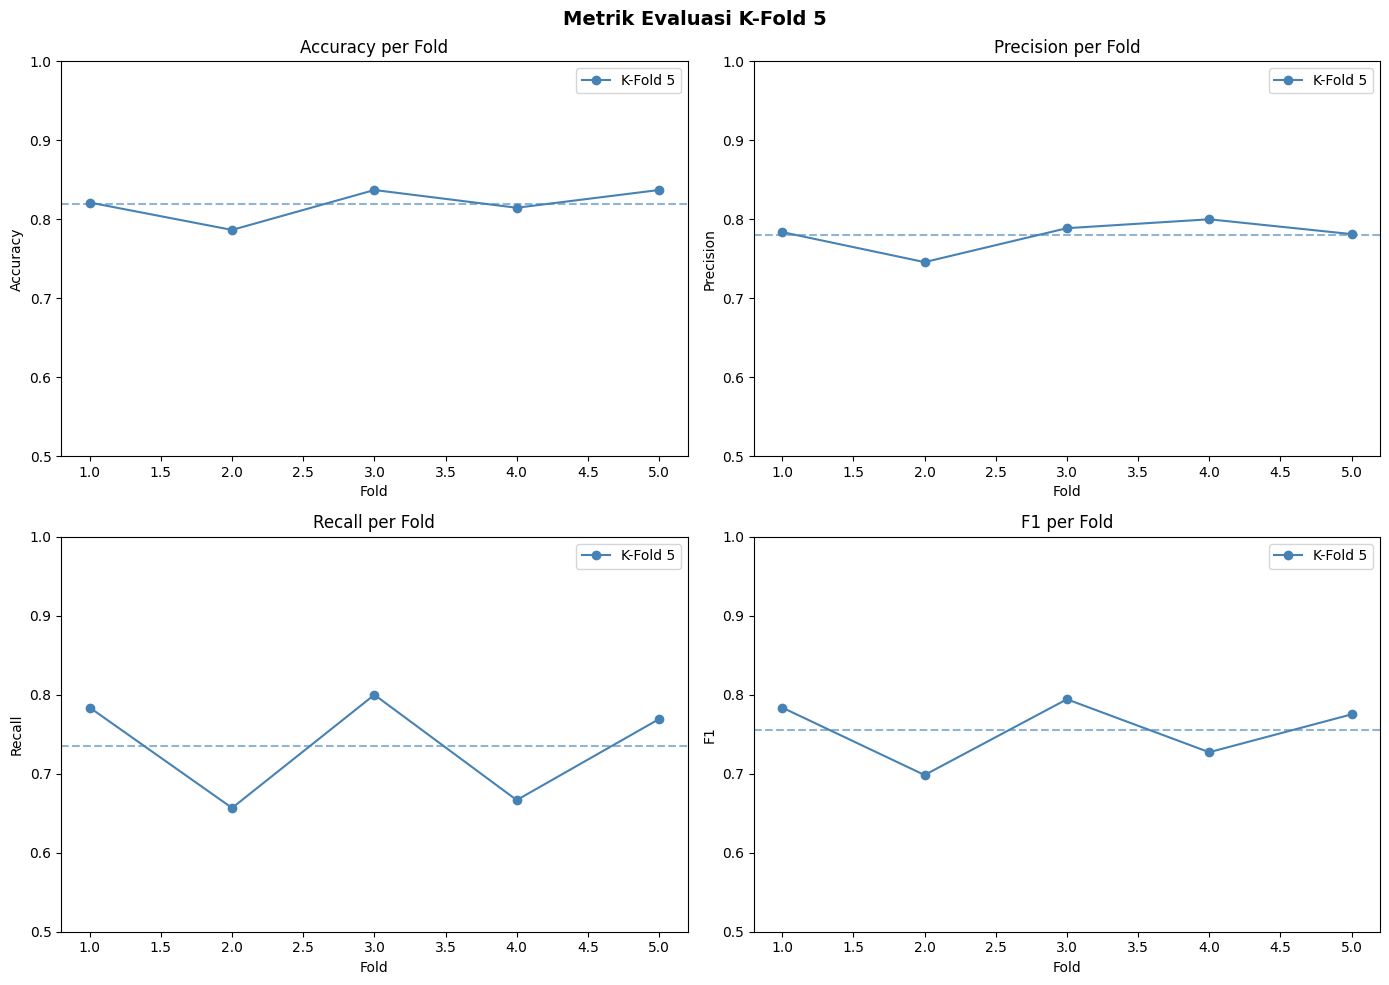

In [ ]:
# Visualisasi perbandingan metrik K-Fold 5
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_names = ['accuracy', 'precision', 'recall', 'f1']

for ax, metric in zip(axes.flatten(), metric_names):
    ax.plot(range(1, 6), metrics_5[metric], 'o-', label='K-Fold 5', color='steelblue')
    ax.axhline(np.mean(metrics_5[metric]), color='steelblue', linestyle='--', alpha=0.6)
    ax.set_title(f'{metric.capitalize()} per Fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.set_ylim(0.5, 1.0)

plt.suptitle('Metrik Evaluasi K-Fold 5', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

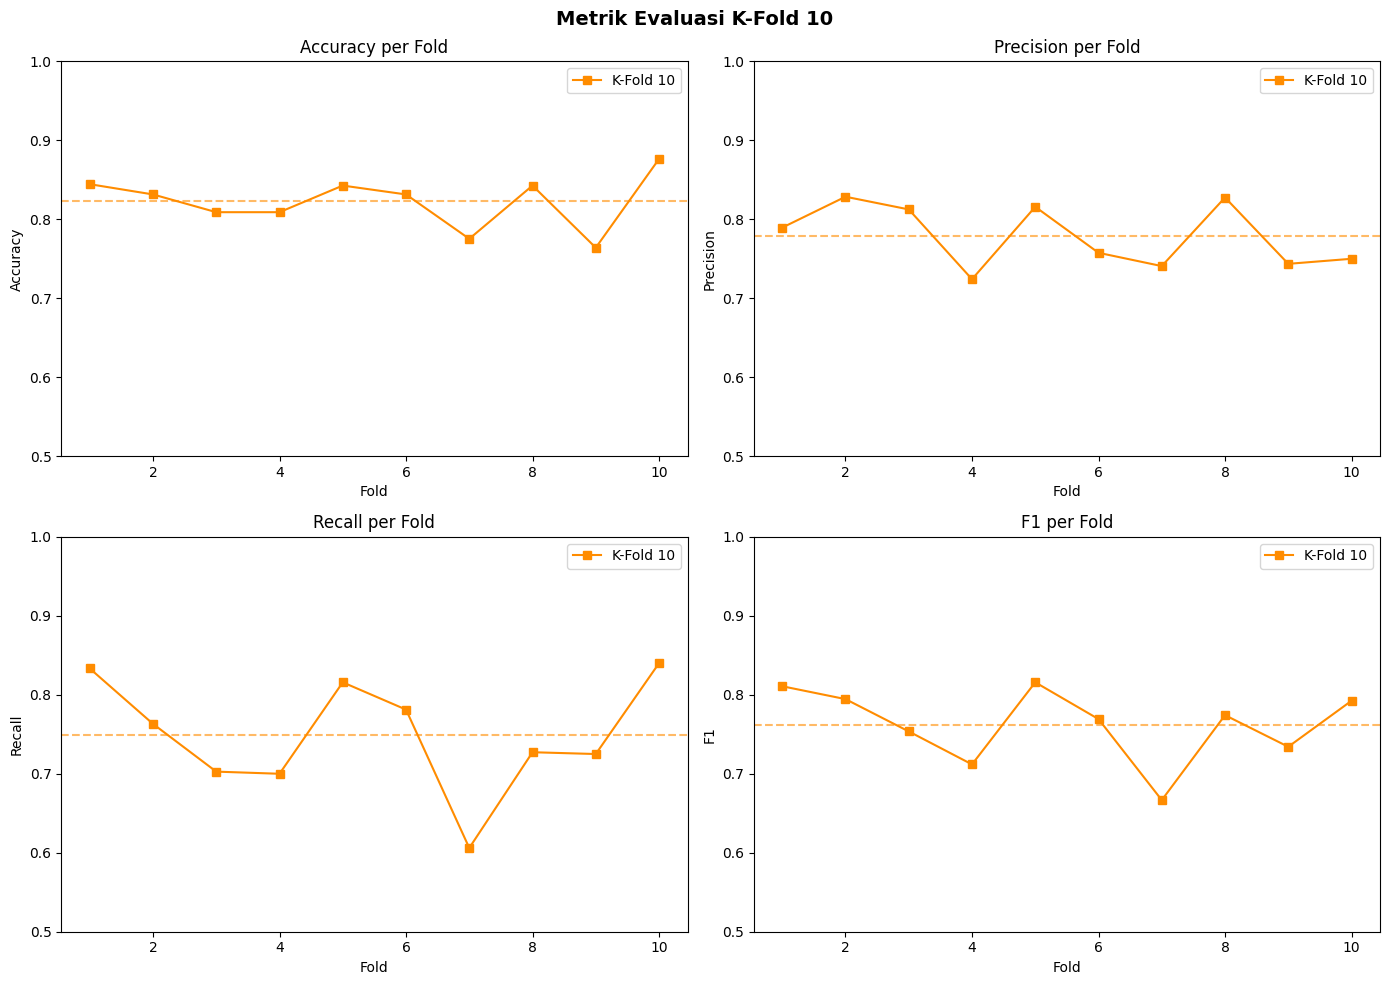

In [ ]:
# Visualisasi perbandingan metrik K-Fold 10
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flatten(), metric_names):
    ax.plot(range(1, 11), metrics_10[metric], 's-', label='K-Fold 10', color='darkorange')
    ax.axhline(np.mean(metrics_10[metric]), color='darkorange', linestyle='--', alpha=0.6)
    ax.set_title(f'{metric.capitalize()} per Fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.set_ylim(0.5, 1.0)

plt.suptitle('Metrik Evaluasi K-Fold 10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Tabel ringkasan perbandingan K-Fold 5 vs K-Fold 10
summary = pd.DataFrame({
    'Metrik': metric_names,
    'KFold-5 Mean': [np.mean(metrics_5[m]) for m in metric_names],
    'KFold-5 Std':  [np.std(metrics_5[m])  for m in metric_names],
    'KFold-10 Mean':[np.mean(metrics_10[m]) for m in metric_names],
    'KFold-10 Std': [np.std(metrics_10[m])  for m in metric_names],
})
summary = summary.set_index('Metrik').round(4)
print(summary.to_string())


           KFold-5 Mean  KFold-5 Std  KFold-10 Mean  KFold-10 Std
Metrik                                                           
accuracy         0.8193       0.0186         0.8226        0.0322
precision        0.7799       0.0182         0.7790        0.0380
recall           0.7353       0.0609         0.7495        0.0686
f1               0.7558       0.0367         0.7623        0.0446


## Confusion Matrix (dari fold terakhir K-Fold 10)

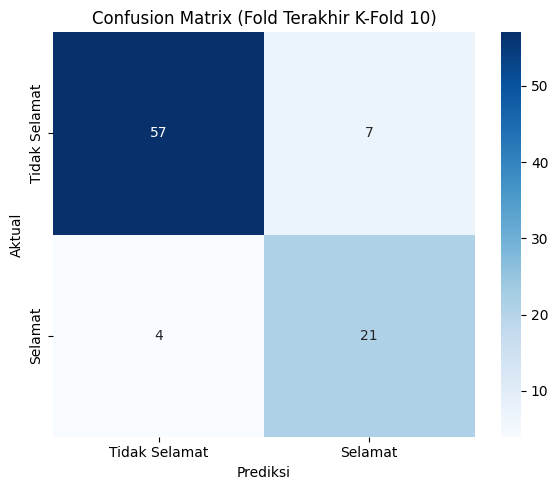


Classification Report (Fold Terakhir K-Fold 10):
               precision    recall  f1-score   support

Tidak Selamat       0.93      0.89      0.91        64
      Selamat       0.75      0.84      0.79        25

     accuracy                           0.88        89
    macro avg       0.84      0.87      0.85        89
 weighted avg       0.88      0.88      0.88        89



In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val_k, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Selamat', 'Selamat'],
            yticklabels=['Tidak Selamat', 'Selamat'], ax=ax)
ax.set_xlabel('Prediksi')
ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix (Fold Terakhir K-Fold 10)')
plt.tight_layout()
plt.show()

print("\nClassification Report (Fold Terakhir K-Fold 10):")
print(classification_report(y_val_k, y_pred, target_names=['Tidak Selamat', 'Selamat']))


## Analisis Kinerja Model

### 1. Metrik Evaluasi
Model Random Forest dievaluasi menggunakan empat metrik:
- **Accuracy**: Proporsi prediksi yang benar secara keseluruhan.
- **Precision**: Dari semua yang diprediksi selamat, berapa yang benar-benar selamat.
- **Recall**: Dari semua yang sebenarnya selamat, berapa yang berhasil terdeteksi.
- **F1-Score**: Harmonic mean antara precision dan recall; berguna saat data tidak seimbang.

### 2. Pengaruh K-Fold Cross Validation
- **K-Fold 5** membagi data menjadi 5 bagian; setiap fold menggunakan 80% data untuk training dan 20% untuk validasi.
- **K-Fold 10** menggunakan fold lebih banyak; setiap fold menggunakan 90% data untuk training sehingga estimasi performa cenderung lebih mendekati kondisi data penuh.
- Dengan cross validation, **setiap data pernah menjadi data uji** minimal satu kali, sehingga evaluasi lebih adil dibanding holdout biasa.
- Nilai **standar deviasi (std)** antar fold mencerminkan stabilitas model. Std yang kecil menandakan model konsisten dan tidak terlalu bergantung pada pembagian data tertentu.
- Secara umum, K-Fold 10 memberikan estimasi yang **sedikit lebih optimistis** karena training data lebih banyak per fold, namun juga membutuhkan waktu komputasi lebih lama.
